In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [14]:
train = pd.read_csv("datatraining.txt")
test1 = pd.read_csv("datatest.txt")
test2 = pd.read_csv("datatest2.txt")

print("Training data:", train.shape)
print("Test 1:", test1.shape)
print("Test 2:", test2.shape)

print("\nColumns:")
print(train.columns.tolist())

Training data: (8143, 7)
Test 1: (2665, 7)
Test 2: (9752, 7)

Columns:
['date', 'Temperature', 'Humidity', 'Light', 'CO2', 'HumidityRatio', 'Occupancy']


In [15]:
print("Training data:")
display(train.head())

print("\nMissing values in training:")
print(train.isnull().sum())

print("\nTarget distribution:")
print(train["Occupancy"].value_counts())

print("\nTarget distribution (%):")
print(train["Occupancy"].value_counts(normalize=True) * 100)

Training data:


,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
1,2015-02-04 17:51:00,23.18,27.2720,426.0,721.25,0.004793,1
2,2015-02-04 17:51:59,23.15,27.2675,429.5,714.00,0.004783,1
3,2015-02-04 17:53:00,23.15,27.2450,426.0,713.50,0.004779,1
4,2015-02-04 17:54:00,23.15,27.2000,426.0,708.25,0.004772,1
5,2015-02-04 17:55:00,23.10,27.2000,426.0,704.50,0.004757,1



Missing values in training:
date             0
Temperature      0
Humidity         0
Light            0
CO2              0
HumidityRatio    0
Occupancy        0
dtype: int64

Target distribution:
Occupancy
0    6414
1    1729
Name: count, dtype: int64

Target distribution (%):
Occupancy
0    78.767039
1    21.232961
Name: proportion, dtype: float64


In [16]:
FEATURES = [
    "Temperature",
    "Humidity",
    "Light",
    "CO2",
    "HumidityRatio"
]

TARGET = "Occupancy"

X_train = train[FEATURES]
y_train = train[TARGET]

X_test1 = test1[FEATURES]
y_test1 = test1[TARGET]

X_test2 = test2[FEATURES]
y_test2 = test2[TARGET]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test1:", X_test1.shape)
print("y_test1:", y_test1.shape)
print("X_test2:", X_test2.shape)
print("y_test2:", y_test2.shape)

X_train: (8143, 5)
y_train: (8143,)
X_test1: (2665, 5)
y_test1: (2665,)
X_test2: (9752, 5)
y_test2: (9752,)


In [17]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

print(model)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)


In [18]:
start_time = time.time()

model.fit(X_train, y_train)

training_time = time.time() - start_time

print(f"Training completed in {training_time:.4f} seconds")

Training completed in 1.1901 seconds


In [19]:
y_pred_test1 = model.predict(X_test1)
y_prob_test1 = model.predict_proba(X_test1)[:, 1]

print("Test 1 predictions completed.")

Test 1 predictions completed.


In [20]:
accuracy1 = accuracy_score(y_test1, y_pred_test1)
precision1 = precision_score(y_test1, y_pred_test1, zero_division=0)
recall1 = recall_score(y_test1, y_pred_test1, zero_division=0)
f1_1 = f1_score(y_test1, y_pred_test1, zero_division=0)
roc_auc1 = roc_auc_score(y_test1, y_prob_test1)

print("===================================")
print("RANDOM FOREST — TEST 1")
print("===================================")
print(f"Accuracy    : {accuracy1:.6f}")
print(f"Precision   : {precision1:.6f}")
print(f"Recall      : {recall1:.6f}")
print(f"F1 Score    : {f1_1:.6f}")
print(f"ROC-AUC     : {roc_auc1:.6f}")
print(f"Training Time: {training_time:.4f} seconds")

RANDOM FOREST — TEST 1
Accuracy    : 0.949343
Precision   : 0.945687
Recall      : 0.913580
F1 Score    : 0.929356
ROC-AUC     : 0.986662
Training Time: 1.1901 seconds


In [21]:
print(classification_report(
    y_test1,
    y_pred_test1,
    target_names=["Unoccupied", "Occupied"],
    zero_division=0
))

              precision    recall  f1-score   support

  Unoccupied       0.95      0.97      0.96      1693
    Occupied       0.95      0.91      0.93       972

    accuracy                           0.95      2665
   macro avg       0.95      0.94      0.94      2665
weighted avg       0.95      0.95      0.95      2665



Test 1 Confusion Matrix:
[[1642   51]
 [  84  888]]


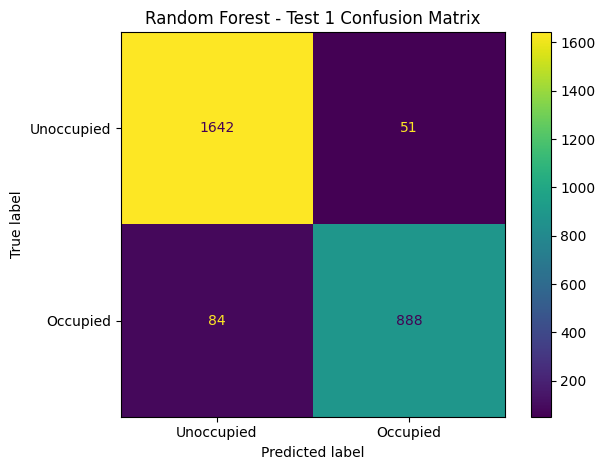

In [22]:
cm1 = confusion_matrix(y_test1, y_pred_test1)

print("Test 1 Confusion Matrix:")
print(cm1)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm1,
    display_labels=["Unoccupied", "Occupied"]
)

disp.plot()
plt.title("Random Forest - Test 1 Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "random_forest_confusion_matrix_test1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
y_pred_test2 = model.predict(X_test2)
y_prob_test2 = model.predict_proba(X_test2)[:, 1]

print("Test 2 predictions completed.")

Test 2 predictions completed.


In [24]:
accuracy2 = accuracy_score(y_test2, y_pred_test2)
precision2 = precision_score(y_test2, y_pred_test2, zero_division=0)
recall2 = recall_score(y_test2, y_pred_test2, zero_division=0)
f1_2 = f1_score(y_test2, y_pred_test2, zero_division=0)
roc_auc2 = roc_auc_score(y_test2, y_prob_test2)

print("===================================")
print("RANDOM FOREST — TEST 2")
print("===================================")
print(f"Accuracy    : {accuracy2:.6f}")
print(f"Precision   : {precision2:.6f}")
print(f"Recall      : {recall2:.6f}")
print(f"F1 Score    : {f1_2:.6f}")
print(f"ROC-AUC     : {roc_auc2:.6f}")
print(f"Training Time: {training_time:.4f} seconds")

RANDOM FOREST — TEST 2
Accuracy    : 0.973031
Precision   : 0.901168
Recall      : 0.979014
F1 Score    : 0.938480
ROC-AUC     : 0.994034
Training Time: 1.1901 seconds


In [25]:
print(classification_report(
    y_test2,
    y_pred_test2,
    target_names=["Unoccupied", "Occupied"],
    zero_division=0
))

              precision    recall  f1-score   support

  Unoccupied       0.99      0.97      0.98      7703
    Occupied       0.90      0.98      0.94      2049

    accuracy                           0.97      9752
   macro avg       0.95      0.98      0.96      9752
weighted avg       0.97      0.97      0.97      9752



Test 2 Confusion Matrix:
[[7483  220]
 [  43 2006]]


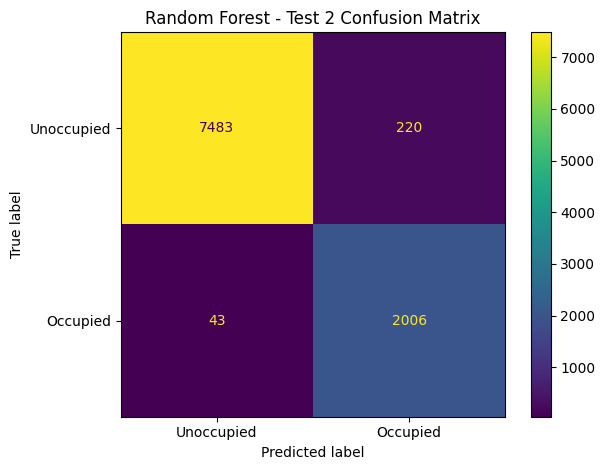

In [26]:
cm2 = confusion_matrix(y_test2, y_pred_test2)

print("Test 2 Confusion Matrix:")
print(cm2)

disp2 = ConfusionMatrixDisplay(
    confusion_matrix=cm2,
    display_labels=["Unoccupied", "Occupied"]
)

disp2.plot()
plt.title("Random Forest - Test 2 Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "random_forest_confusion_matrix_test2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Feature Importance:
Light            0.620181
CO2              0.232927
Temperature      0.088726
HumidityRatio    0.031843
Humidity         0.026323
dtype: float64


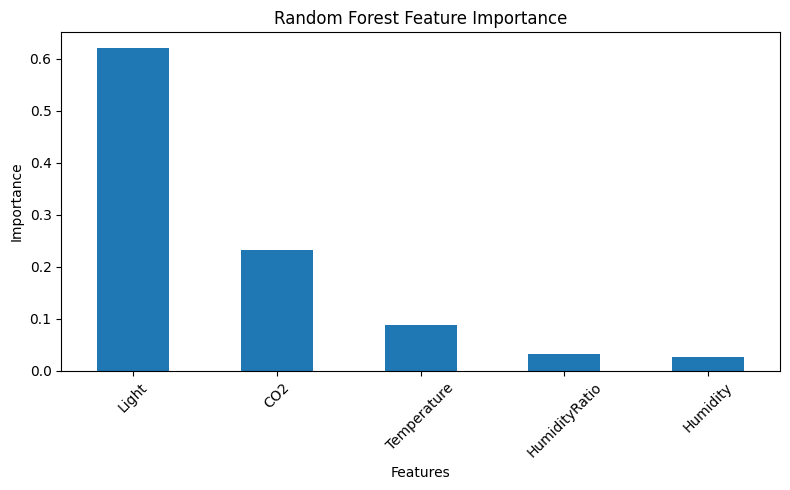

In [27]:
importance = pd.Series(
    model.feature_importances_,
    index=FEATURES
).sort_values(ascending=False)

print("Feature Importance:")
print(importance)

plt.figure(figsize=(8, 5))

importance.plot(kind="bar")

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
results = pd.DataFrame([
    {
        "Model": "Random Forest",
        "Test Set": "Test 1",
        "Accuracy": accuracy1,
        "Precision": precision1,
        "Recall": recall1,
        "F1": f1_1,
        "ROC-AUC": roc_auc1,
        "Training Time": training_time
    },
    {
        "Model": "Random Forest",
        "Test Set": "Test 2",
        "Accuracy": accuracy2,
        "Precision": precision2,
        "Recall": recall2,
        "F1": f1_2,
        "ROC-AUC": roc_auc2,
        "Training Time": training_time
    }
])

display(results)

,Model,Test Set,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time
0,Random Forest,Test 1,0.949343,0.945687,0.913580,0.929356,0.986662,1.190053
1,Random Forest,Test 2,0.973031,0.901168,0.979014,0.938480,0.994034,1.190053


In [29]:
results.to_csv(
    "random_forest_results.csv",
    index=False
)

print("Results saved successfully!")

Results saved successfully!


In [30]:
from google.colab import files

files.download("random_forest_results.csv")
files.download("random_forest_confusion_matrix_test1.png")
files.download("random_forest_confusion_matrix_test2.png")
files.download("random_forest_feature_importance.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>